# CSoT'26 - ML in Astronomy - Week 3 . Part 2: Evaluation and Interpretation (Starter)

**Goal:** Evaluate the CNN honestly. Track train-vs-validation loss, report a **test accuracy** that beats the Week-2 baseline, build a **confusion matrix** you can read astrophysically, and **save** the trained weights.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`).
2. Read [`05-evaluation-and-overfitting.md`](../05-evaluation-and-overfitting.md), [`06-confusion-matrix-and-metrics.md`](../06-confusion-matrix-and-metrics.md), and [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).

Replace each `TODO`. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Data + model

Re-create the Week-1 `DataLoader`s and your `GalaxyCNN` (paste both from Part 1). You can either re-train here, or load Part 1's `galaxy_model.pth`. After this section you need: `train_loader`, `val_loader`, `test_loader`, `test_ds`, `num_classes`, `model`, `criterion`, `optimizer`.

In [1]:
import math
import os
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [2]:
# TODO: paste the Week-1 data pipeline AND your GalaxyCNN definition from Part 1, so that
#   train_loader, val_loader, test_loader, test_ds, num_classes, model, criterion, optimizer
# are all defined. Move model to device. (Optionally load Part-1 weights:
#   model.load_state_dict(torch.load('galaxy_model.pth', map_location=device)) )

In [3]:
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('username')
os.environ['KAGGLE_KEY'] = userdata.get('gal_morph')

RAW_ROOT = Path("galaxy_raw")      # <-- set up download here
IMAGES_DIR = RAW_ROOT / "images_gz2" /"images"  # flat image folder
DATA_ROOT = Path("galaxy_data")    # ImageFolder root (built in Step 3)

RAW_ROOT.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}
!unzip -q {RAW_ROOT}/galaxy-zoo-2-images.zip -d {RAW_ROOT}
print("Files extracted")

print("Downloading gz2_hart16.csv")
!wget -P {RAW_ROOT} https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

print("Extracting labels file")
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

def high_level_label(gz2_class):
  if "E" in gz2_class:
    return "elliptical"
  elif "SB" in gz2_class:
    return "spiral_barred"
  elif "S" in gz2_class:
    return "spiral"
  else:
    return None

def build_imagefolder_layout(images_dir, mapping_csv,labels_csv, out_root, per_class=200, seed=42,
):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts


PER_CLASS = 200
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:38<00:00, 84.6MB/s]

Files extracted
--2026-06-21 12:51:20--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 16.15.254.24, 52.217.226.17, 52.217.165.25, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|16.15.254.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘galaxy_raw/gz2_hart16.csv.gz’

gz2_hart16.csv.gz   100%[===================>]  74.88M  44.3MB/s    in 1.7s    

2026-06-21 12:51:22 (44.3 MB/s) - ‘galaxy_raw/gz2_hart16.csv.gz’ saved [78513011/78513011]

Extracting labels file
Symlinked per class: {'elliptical': 200, 'spiral': 200, 'spiral_barred': 200}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


In [107]:
from torchvision import transforms
import copy

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])
dataset = ImageFolder(root=DATA_ROOT, transform=train_transform)
total_size = len(dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)
val_ds = copy.deepcopy(val_ds)
val_ds.dataset.transform = transform

test_ds = copy.deepcopy(test_ds)
test_ds.dataset.transform = transform

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.dataset.classes)

In [108]:
class GalaxyCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2))
    self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Dropout(p=0.4),
          nn.Linear(64 * 16 * 16, 128),
          nn.ReLU(),
          nn.Dropout(p=0.3),
          nn.Linear(128, num_classes)
      )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

model = GalaxyCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr = 3e-4)

In [88]:
from google.colab import drive
drive.mount("/content/drive")
model.load_state_dict(torch.load("/content/drive/MyDrive/galaxy_model.pth", map_location=device))
model.to(device)
print("Model weights loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model weights loaded.


## Step 1 - The evaluation function

Write `evaluate(model, loader, criterion, device)` that returns `(avg_loss, accuracy)`. It MUST use `model.eval()` and `torch.no_grad()`. Predicted class = `outputs.argmax(dim=1)`.

In [109]:
# TODO: define evaluate(model, loader, criterion, device):
#   model.eval(); total_loss=correct=total=0
#   with torch.no_grad():
#       for inputs, targets in loader:
#           inputs, targets = inputs.to(device), targets.to(device)
#           outputs = model(inputs); loss = criterion(outputs, targets)
#           total_loss += loss.item() * inputs.size(0)
#           preds = outputs.argmax(dim=1)
#           correct += (preds == targets).sum().item(); total += targets.size(0)
#   return total_loss/total, correct/total

def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss, correct, total = 0.0, 0, 0
  with torch.no_grad():
    for inputs, targets in loader:
      inputs, targets = inputs.to(device), targets.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      total_loss += loss.item() * inputs.size(0)
      preds = outputs.argmax(dim=1)
      correct += (preds == targets).sum().item()
      total += targets.size(0)
    return total_loss/total, correct/total #avg, acc

## Step 2 - Train while tracking validation

Run the training loop again, but each epoch also call `evaluate(model, val_loader, ...)`. Record `train_losses` and `val_losses` (and optionally `val_accs`).

In [113]:
# TODO: num_epochs=8; train_losses=[]; val_losses=[]
#   for epoch in range(num_epochs):
#       model.train(); running=0.0
#       for inputs, targets in train_loader:
#           inputs, targets = inputs.to(device), targets.to(device)
#           optimizer.zero_grad(); out=model(inputs); loss=criterion(out, targets)
#           loss.backward(); optimizer.step(); running += loss.item()*inputs.size(0)
#       train_losses.append(running/len(train_loader.dataset))
#       vl, va = evaluate(model, val_loader, criterion, device)
#       val_losses.append(vl)
#       print(f"epoch {epoch+1}: train {train_losses[-1]:.3f}  val {vl:.3f}  val_acc {va:.3f}")

num_epochs = 8
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    model.train()
    running=0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimiser.zero_grad()
        out=model(inputs)
        loss=criterion(out, targets)
        loss.backward()
        optimiser.step()
        running += loss.item()*inputs.size(0)
    train_losses.append(running/len(train_loader.dataset))
    vl, va = evaluate(model, val_loader, criterion, device)
    val_losses.append(vl)
    print(f"epoch {epoch+1}: train {train_losses[-1]:.3f}  val {vl:.3f}  val_acc {va:.3f}")

epoch 1: train 0.888  val 0.925  val_acc 0.533
epoch 2: train 0.918  val 0.925  val_acc 0.533
epoch 3: train 0.893  val 0.930  val_acc 0.533
epoch 4: train 0.884  val 0.924  val_acc 0.511
epoch 5: train 0.880  val 0.949  val_acc 0.544
epoch 6: train 0.908  val 0.924  val_acc 0.500
epoch 7: train 0.865  val 0.937  val_acc 0.544
epoch 8: train 0.868  val 0.919  val_acc 0.556


## Step 3 - Plot train vs validation loss

Plot both on one axis. A widening gap (train falling, val rising) is the overfitting signature.

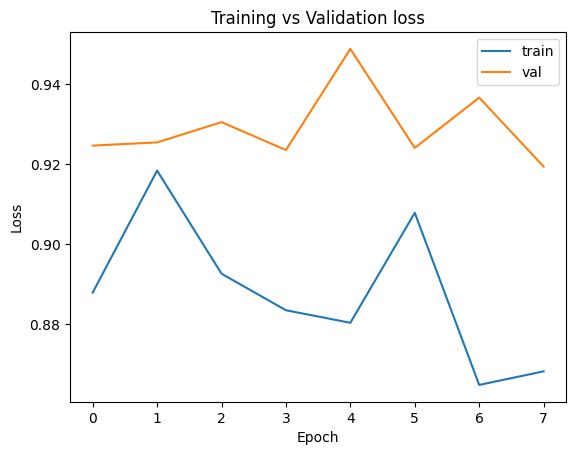

In [114]:
# TODO: plt.plot(train_losses, label='train'); plt.plot(val_losses, label='val')
#       label axes; legend; title; show. Then comment (Markdown) on overfitting.
plt.plot(train_losses, label = 'train')
plt.plot(val_losses, label = 'val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation loss')
plt.legend()
plt.show()

the trend for both train_loss and val_loss are downward, hence there are no severe signs of overfitting. nevertheless there are spikes in certain epochs, but they need not necessarily be due to overfitting(giving it a few more epochs can perhaps confirm this).

## Step 4 - Final test accuracy vs the Week-2 baseline

Evaluate ONCE on the test set. State your Week-2 baseline number and the improvement.

In [115]:
# TODO: test_loss, test_acc = evaluate(model, test_loader, criterion, device)
#       print(f"test accuracy: {test_acc:.3f}")
#       baseline = ...  # your Week-2 KNN/LogReg test accuracy
#       print(f"beat baseline by {test_acc - baseline:+.3f}")

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"test accuracy: {test_acc:.3f}")
baseline = 0.478
print(f"beat baseline by {test_acc - baseline:+.3f}")

test accuracy: 0.600
beat baseline by +0.122


## Step 5 - Confusion matrix

Collect predictions across the test set (move them to CPU before NumPy!), then display a labelled confusion matrix using `test_ds.classes`.

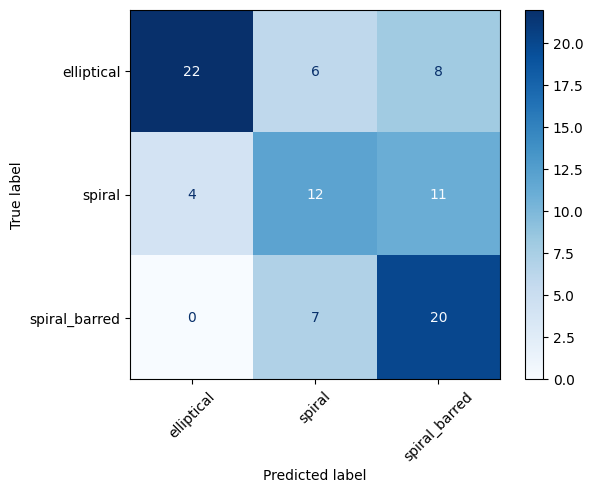

In [116]:
# TODO: model.eval(); all_preds=[]; all_labels=[]
#   with torch.no_grad():
#       for inputs, targets in test_loader:
#           preds = model(inputs.to(device)).argmax(dim=1).cpu()
#           all_preds.append(preds); all_labels.append(targets)
#   y_pred = torch.cat(all_preds).numpy(); y_true = torch.cat(all_labels).numpy()
#   cm = confusion_matrix(y_true, y_pred)
#   ConfusionMatrixDisplay(cm, display_labels=test_ds.classes).plot(cmap='Blues', xticks_rotation=45)
#   plt.show()

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        preds = model(inputs.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds); all_labels.append(targets)
y_pred = torch.cat(all_preds).numpy(); y_true = torch.cat(all_labels).numpy()
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=test_ds.dataset.classes).plot(cmap='Blues', xticks_rotation=45)
plt.show()

## Step 6 - Per-class report + astrophysical reading

Print `classification_report`, then in a Markdown cell name the most-confused pair and link it to the astronomy (density waves / bars in [`04`](../04-spiral-structure-and-star-formation.md); lenticulars / mergers in [`08`](../08-lenticulars-mergers-and-evolution.md)).

In [117]:
# TODO: print(classification_report(y_true, y_pred, target_names=test_ds.classes))
print(classification_report(y_true, y_pred, target_names=test_ds.dataset.classes))

               precision    recall  f1-score   support

   elliptical       0.85      0.61      0.71        36
       spiral       0.48      0.44      0.46        27
spiral_barred       0.51      0.74      0.61        27

     accuracy                           0.60        90
    macro avg       0.61      0.60      0.59        90
 weighted avg       0.64      0.60      0.60        90



the most confused pair is without doubt `Spiral and Barred Spiral` with 11 spiral being classified as spiral_barred and 7 spiral_barred being classified as spiral. the bar(i.e. the differentiator between the two) is a subtle feature to identify and thus the model confuses the two.

## Step 7 - Save and reload (round-trip check)

Save the `state_dict`, load it into a fresh `GalaxyCNN`, and assert the reloaded test accuracy matches the original.

In [118]:
# TODO: torch.save(model.state_dict(), 'galaxy_model.pth')
#   loaded = GalaxyCNN(num_classes=num_classes).to(device)
#   loaded.load_state_dict(torch.load('galaxy_model.pth', map_location=device)); loaded.eval()
#   _, acc2 = evaluate(loaded, test_loader, criterion, device)
#   assert abs(acc2 - test_acc) < 1e-6; print('round-trip verified:', acc2)

torch.save(model.state_dict(), "/content/drive/MyDrive/galaxy_model.pth")
loaded = GalaxyCNN(num_classes=num_classes).to(device)
loaded.load_state_dict(torch.load("/content/drive/MyDrive/galaxy_model.pth", map_location=device)); loaded.eval()
_, acc2 = evaluate(loaded, test_loader, criterion, device)
assert abs(acc2 - test_acc) < 1e-6
print('round-trip verified:', acc2)

round-trip verified: 0.6


## Reflection *(write 2-3 sentences each)*

1. What test accuracy did you reach, and by how much did the CNN beat the Week-2 baseline?
2. Did your curves show overfitting? How could you tell, and what would you try next?
3. Which two classes were confused most, and is that a model failure, a real physical ambiguity, or both?
4. Why is the save/reload round-trip check worth running rather than assuming it worked?

*1. reached 0.6, 12.2% more than the baseline*<br>
*2. there were signs of overfitting in the baseline CNN(as in `week3_cnn_starter`) identified by seeing the increasing val_loss. tried data augmentation, increasing the depth, lowering the lr, adding Dropout and BatchNorm.*<br>
*3. spiral and spiral_barred, both(angle issue or the feature capacity)*<br>
*4. confident shipping + exposes the data leaks(e.g. I added random augmentations but forgot to change them for the val and test)*